In [1]:
import math
import numpy as np
from sofya.brain import MLP
import matplotlib.pyplot as plt

In [2]:
# our model
model = MLP(1, [16, 16, 1], ["tanh", "tanh", "tanh"])

Text(0, 0.5, 'sin(x)')

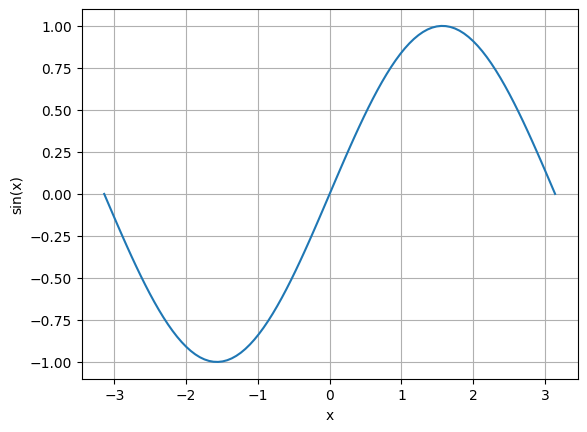

In [8]:
# generating the data to train on
xs = np.linspace(-math.pi,math.pi,100)
ys = [math.sin(x) for x in xs]

plt.plot(xs, ys)
plt.grid()
plt.xlabel("x")
plt.ylabel("sin(x)")

In [4]:
# training the model
epochs = 300
learning_rate = 0.1
for e in range(epochs):
    # forward pass
    ypreds = [model([x]) for x in xs]
    loss = sum((ypred[0] - ygt) ** 2 for ypred, ygt in zip(ypreds, ys)) / len(ys)

    # backward pass
    model.grad_zero()
    loss.backwards()

    # optimization
    for p in model.parameters():
        p.data -= learning_rate * p.grad


In [5]:
xs = np.linspace(-math.pi, math.pi, 100)
ypreds = [model([x]) for x in xs]
ys = [ypred[0].data for ypred in ypreds]

Text(0, 0.5, 'sin(x)')

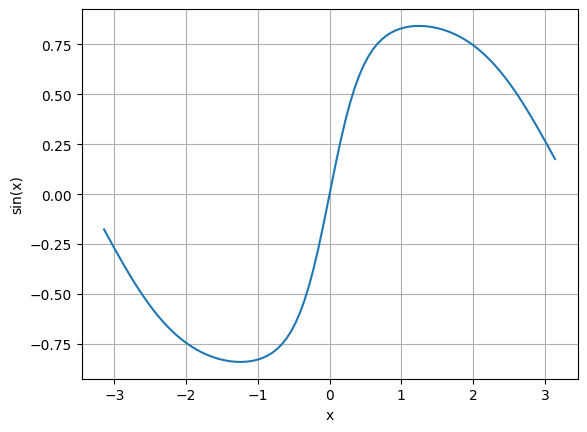

In [7]:
plt.plot(xs, ys)
plt.grid()
plt.xlabel("x")
plt.ylabel("sin(x)")